In [1]:
input_density_path = f"/export/scratch/ialgroup/mklockow/boa_vasp_preds_matched_split_100"

comparison_density_path = "/export/home/mickler/scdp/models/qm9_bond_K8L6_beta_1.3_vo_backup/predictions_test"
comparison_split_file = "/export/scratch/mklockow/boa/data/qm9_vasp/datasplits.json"

# show files in folder
import os

import torch
print("Input density files:", os.listdir(input_density_path))
print("Comparison density files:", os.listdir(comparison_density_path))

print(torch.load("/export/home/mickler/scdp/models/qm9_bond_K8L6_beta_1.3_vo_backup/predictions_test/pred_6252.pt", weights_only=False))
print(torch.load("/export/home/mickler/scdp/models/qm9_bond_K8L6_beta_1.3_vo_backup/predictions_test/pred_6252.pt", weights_only=False)["test_index"])

Input density files: ['44_164.npy', '45_560.npy', '128_832.npy', '16_576.npy', '7_905.npy', '73_592.npy', '49_5.npy', '30_839.npy', '126_380.npy', '7_828.npy', '23_647.npy', '5_933.npy', '130_230.npy', '132_676.npy', '30_60.npy', '123_81.npy', '70_846.npy', '70_285.npy', '41_903.npy', '50_728.npy', '109_309.npy', '103_451.npy', '108_365.npy', '34_61.npy', '102_787.npy', '13_187.npy', '113_956.npy', '117_717.npy', '41_769.npy', '20_783.npy', '36_686.npy', '38_403.npy', '27_267.npy', '10_789.npy', '84_90.npy', '88_231.npy', '49_842.npy', '111_125.npy', '74_949.npy', '66_5.npy', '3_256.npy', '47_68.npy', '34_538.npy', '80_255.npy', '82_484.npy', '122_341.npy', '61_278.npy', '110_615.npy', '35_671.npy', '69_489.npy', '65_364.npy', '105_195.npy', '61_931.npy', '99_654.npy', '98_445.npy', '82_774.npy', '38_617.npy', '39_919.npy', '40_376.npy', '98_961.npy', '40_238.npy', '77_534.npy', '105_422.npy', '59_765.npy', '108_498.npy', '95_263.npy', '124_97.npy', '39_40.npy', '23_251.npy', '65_332.n

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# Check if GPU is available
device = "cuda:4"
print(f"Using device: {device}")

# Load all prediction files
comparison_path = Path(comparison_density_path)
pred_files = sorted(comparison_path.glob("pred_*.pt"))

print(f"Found {len(pred_files)} prediction files")

all_errors = []
all_distances = []

for pred_file in tqdm(pred_files[:100]):  # Remove [:] or change to limit files
    try:
        data = torch.load(pred_file, weights_only=False)
        
        # Extract prediction and label tensors (keep on GPU)
        prediction = data['prediction'].to(device).flatten()
        label = data['label'].to(device).flatten()
        
        # Calculate absolute error on GPU
        abs_error = torch.abs(prediction - label)
        
        # Get batch object
        batch = data['batch']
        
        # Get probe coordinates (keep on GPU)
        probe_coords = batch.probe_coords.to(device)  # Shape: (n_probes, 3)
        
        # Get atom coordinates (mask virtual nodes, keep on GPU)
        is_vnode = batch.is_vnode.to(device)
        atom_coords = batch.coords.to(device)[~is_vnode]  # Shape: (n_atoms, 3)
        
        # Compute distance from each probe point to nearest atom on GPU
        # Using torch.cdist for GPU acceleration
        distances = torch.cdist(probe_coords.unsqueeze(0), atom_coords.unsqueeze(0)).squeeze(0)
        min_distances = distances.min(dim=1)[0]  # Distance to nearest atom for each probe
        
        # Move results to CPU and convert to numpy for storage
        all_errors.extend(abs_error.cpu().numpy().tolist())
        all_distances.extend(min_distances.cpu().numpy().tolist())
        
    except Exception as e:
        print(f"Error processing {pred_file.name}: {e}")
        continue

# Convert to numpy arrays
all_errors = np.array(all_errors)
all_distances = np.array(all_distances)

print(f"\nTotal probe points analyzed: {len(all_errors)}")
print(f"Distance range: {all_distances.min():.3f} to {all_distances.max():.3f}")
print(f"Error range: {all_errors.min():.6f} to {all_errors.max():.6f}")
print(f"Mean error: {all_errors.mean():.6f}")
print(f"Median error: {np.median(all_errors):.6f}")

Using device: cuda:4
Found 100 prediction files


100%|██████████| 100/100 [00:10<00:00,  9.44it/s]



Total probe points analyzed: 67916864
Distance range: 0.004 to 8.616
Error range: 0.000000 to 0.735722
Mean error: 0.000128
Mean error: 0.000128
Median error: 0.000023
Median error: 0.000023


In [3]:
import json

# Load the original datasplits.json to understand the format
with open(comparison_split_file, 'r') as f:
    datasplits = json.load(f)

print("Original datasplits format:")
print(f"  Keys: {list(datasplits.keys())}")
print(f"  Train samples: {len(datasplits.get('train', []))}")
print(f"  Val samples: {len(datasplits.get('val', []))}")
print(f"  Test samples: {len(datasplits.get('test', []))}")

# Get test IDs list
test_ids = datasplits['test']

# Load all prediction files and extract the actual molecule IDs
comparison_path = Path(comparison_density_path)
pred_files = sorted(comparison_path.glob("pred_*.pt"))

print(f"\nFound {len(pred_files)} prediction files")

# Create mapping from test_index to actual ID
test_index_to_id = {i: test_ids[i] for i in range(len(test_ids))}

# Collect all actual IDs from the prediction files
actual_test_ids = []

for pred_file in tqdm(pred_files, desc="Extracting IDs"):
    try:
        data = torch.load(pred_file, weights_only=False)
        test_index = data['test_index'].item() if torch.is_tensor(data['test_index']) else data['test_index']
        
        # Map test_index to actual ID
        actual_id = test_index_to_id[test_index]
        actual_test_ids.append(actual_id)
        
    except Exception as e:
        print(f"Error processing {pred_file.name}: {e}")
        continue

print(f"\nExtracted {len(actual_test_ids)} test IDs")
print(f"First 10 IDs: {actual_test_ids[:10]}")

# Create new datasplits with only test split populated
new_datasplits = {
    "train": [],
    "val": [],
    "test": actual_test_ids
}

# Save to new file
output_file = "test_split_small.json"
with open(output_file, 'w') as f:
    json.dump(new_datasplits, f, indent=2)

print(f"\n✅ Created {output_file}")
print(f"   Train: {len(new_datasplits['train'])} samples")
print(f"   Val: {len(new_datasplits['val'])} samples")
print(f"   Test: {len(new_datasplits['test'])} samples")

Original datasplits format:
  Keys: ['test', 'train', 'validation']
  Train samples: 123835
  Val samples: 0
  Test samples: 10000

Found 100 prediction files


Extracting IDs:   0%|          | 0/100 [00:00<?, ?it/s]

Extracting IDs: 100%|██████████| 100/100 [00:00<00:00, 152.55it/s]


Extracted 100 test IDs
First 10 IDs: [14712, 1258, 16575, 18139, 20782, 23250, 23646, 26346, 27266, 30059]

✅ Created test_split_small.json
   Train: 0 samples
   Val: 0 samples
   Test: 100 samples


In [4]:
# # Compare shapes between .npy files and .pt predictions
# import numpy as np
# from pathlib import Path

# # Get all .npy files from input_density_path
# input_path = Path(input_density_path)
# npy_files = sorted(input_path.glob("*.npy"))

# print(f"Found {len(npy_files)} .npy files")

# # Load all .npy file shapes
# npy_shapes = []
# npy_file_info = []

# for npy_file in tqdm(npy_files, desc="Loading .npy shapes"):
#     try:
#         data = np.load(npy_file)
#         shape = data.shape
#         flattened_size = data.flatten().shape[0]
#         npy_shapes.append(flattened_size)
#         npy_file_info.append({
#             'file': npy_file.name,
#             'shape': shape,
#             'flattened_size': flattened_size
#         })
#     except Exception as e:
#         print(f"Error loading {npy_file.name}: {e}")

# # Load all .pt prediction shapes
# comparison_path = Path(comparison_density_path)
# pred_files = sorted(comparison_path.glob("pred_*.pt"))

# print(f"Found {len(pred_files)} .pt prediction files")

# pt_shapes = []
# pt_file_info = []

# for pred_file in tqdm(pred_files, desc="Loading .pt shapes"):
#     try:
#         data = torch.load(pred_file, weights_only=False)
#         pred_shape = data['prediction'].shape
#         flattened_size = data['prediction'].flatten().shape[0]
#         pt_shapes.append(flattened_size)
#         pt_file_info.append({
#             'file': pred_file.name,
#             'shape': pred_shape,
#             'flattened_size': flattened_size,
#             'test_index': data['test_index'].item() if torch.is_tensor(data['test_index']) else data['test_index']
#         })
#     except Exception as e:
#         print(f"Error loading {pred_file.name}: {e}")

# # Sort shapes
# npy_shapes_sorted = sorted(npy_shapes)
# pt_shapes_sorted = sorted(pt_shapes)

# print(f"\n{'='*60}")
# print("SHAPE COMPARISON")
# print(f"{'='*60}")
# print(f"Number of .npy files: {len(npy_shapes_sorted)}")
# print(f"Number of .pt files: {len(pt_shapes_sorted)}")

# # Compare if we have the same number
# if len(npy_shapes_sorted) != len(pt_shapes_sorted):
#     print(f"\n⚠️ Different number of files!")
#     print(f"   .npy: {len(npy_shapes_sorted)}")
#     print(f"   .pt:  {len(pt_shapes_sorted)}")
# else:
#     print(f"\n✅ Same number of files: {len(npy_shapes_sorted)}")

# # Compare sorted shapes
# print(f"\n{'='*60}")
# print("Sorted shape comparison:")
# print(f"{'='*60}")

# # Check if all shapes match
# all_match = all(n == p for n, p in zip(npy_shapes_sorted, pt_shapes_sorted))

# if all_match:
#     print(f"✅ ALL SHAPES MATCH when sorted!")
#     print(f"\nFirst 10 shapes (flattened sizes):")
#     for i in range(min(10, len(npy_shapes_sorted))):
#         print(f"  {i+1}. .npy: {npy_shapes_sorted[i]:,} == .pt: {pt_shapes_sorted[i]:,}")
# else:
#     print(f"❌ Shapes DON'T match when sorted")
#     print(f"\nFirst 10 comparisons:")
#     for i in range(min(100, len(npy_shapes_sorted), len(pt_shapes_sorted))):
#         match = "✓" if npy_shapes_sorted[i] == pt_shapes_sorted[i] else "✗"
#         print(f"  {i+1}. {match} .npy: {npy_shapes_sorted[i]:,} vs .pt: {pt_shapes_sorted[i]:,}")

# # Show unique shapes
# print(f"\n{'='*60}")
# print("Unique shapes analysis:")
# print(f"{'='*60}")
# unique_npy_shapes = sorted(set(npy_shapes))
# unique_pt_shapes = sorted(set(pt_shapes))

# print(f"Unique .npy shapes: {len(unique_npy_shapes)}")
# if len(unique_npy_shapes) <= 20:
#     for shape in unique_npy_shapes:
#         count = npy_shapes.count(shape)
#         print(f"  {shape:,}: {count} files")

# print(f"\nUnique .pt shapes: {len(unique_pt_shapes)}")
# if len(unique_pt_shapes) <= 20:
#     for shape in unique_pt_shapes:
#         count = pt_shapes.count(shape)
#         print(f"  {shape:,}: {count} files")

# # Statistics
# print(f"\n{'='*60}")
# print("Shape statistics:")
# print(f"{'='*60}")
# print(f".npy flattened sizes:")
# print(f"  Min: {min(npy_shapes):,}")
# print(f"  Max: {max(npy_shapes):,}")
# print(f"  Mean: {np.mean(npy_shapes):,.0f}")
# print(f"  Median: {np.median(npy_shapes):,.0f}")

# print(f"\n.pt flattened sizes:")
# print(f"  Min: {min(pt_shapes):,}")
# print(f"  Max: {max(pt_shapes):,}")
# print(f"  Mean: {np.mean(pt_shapes):,.0f}")
# print(f"  Median: {np.median(pt_shapes):,.0f}")

Text(0.05, 0.95, '50% error at distance: 1.052\n90% error at distance: 2.337')

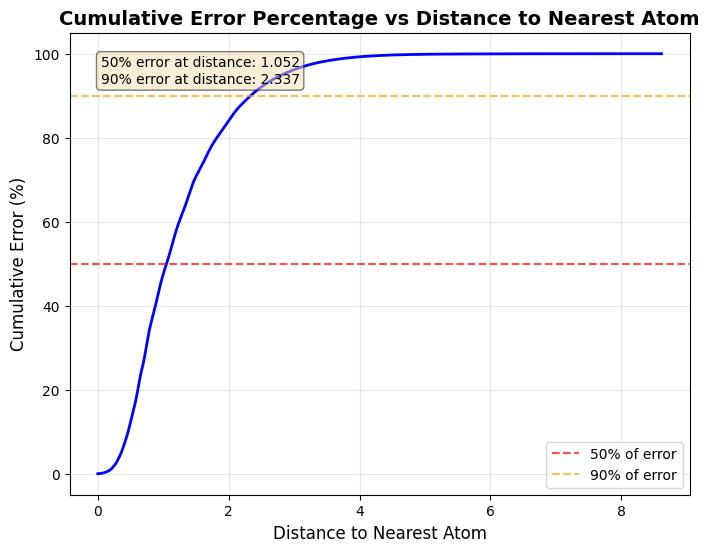

In [5]:
# Calculate cumulative error percentage vs distance
# Sort by distance
sorted_indices = np.argsort(all_distances)
sorted_distances = all_distances[sorted_indices]
sorted_errors = all_errors[sorted_indices]

# Calculate cumulative error
cumulative_error = np.cumsum(sorted_errors)
total_error = cumulative_error[-1]

# Calculate percentage of total error at each distance
error_percentage = (cumulative_error / total_error) * 100

# Create distance bins for smoother plot
distance_bins = np.linspace(0, sorted_distances.max(), 1000)
error_pct_at_distance = np.interp(distance_bins, sorted_distances, error_percentage)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot 1: Cumulative error percentage vs distance
ax.plot(distance_bins, error_pct_at_distance, linewidth=2, color='blue')
ax.axhline(50, color='red', linestyle='--', alpha=0.7, label='50% of error')
ax.axhline(90, color='orange', linestyle='--', alpha=0.7, label='90% of error')
ax.set_xlabel('Distance to Nearest Atom', fontsize=12)
ax.set_ylabel('Cumulative Error (%)', fontsize=12)
ax.set_title('Cumulative Error Percentage vs Distance to Nearest Atom', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Find distance at which 50% and 90% of error is accumulated
dist_50 = distance_bins[np.argmin(np.abs(error_pct_at_distance - 50))]
dist_90 = distance_bins[np.argmin(np.abs(error_pct_at_distance - 90))]
ax.text(0.05, 0.95, f'50% error at distance: {dist_50:.3f}\n90% error at distance: {dist_90:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


In [6]:
# Parse .npy filenames and match with .pt files
import re

# Create inverse mapping: actual_id -> test_index
test_ids = datasplits['test']
id_to_test_index = {test_ids[i]: i for i in range(len(test_ids))}

print(f"Created inverse mapping with {len(id_to_test_index)} entries")

# Parse .npy filenames to get IDs
input_path = Path(input_density_path)
npy_files = sorted(input_path.glob("*.npy"))

npy_id_mapping = []
for npy_file in npy_files:
    # Parse filename like "132_419.npy"
    match = re.match(r'(\d+)_(\d+)\.npy', npy_file.name)
    if match:
        num1, num2 = int(match.group(1)), int(match.group(2))
        molecule_id = num1 * 1000 + num2 - 1 if not num1 == 0 else num2 
        npy_id_mapping.append({
            'file': npy_file.name,
            'path': npy_file,
            'molecule_id': molecule_id,
            'test_index': id_to_test_index.get(molecule_id)
        })
    else:
        print(f"⚠️ Could not parse filename: {npy_file.name}")

print(f"\nParsed {len(npy_id_mapping)} .npy files")
print(f"First 10 mappings:")
for i, entry in enumerate(npy_id_mapping[:10]):
    print(f"  {entry['file']}: ID={entry['molecule_id']}, test_index={entry['test_index']}")

# Create mapping: test_index -> pt_file
pt_index_to_file = {}
for pred_file in pred_files:
    try:
        data = torch.load(pred_file, weights_only=False)
        test_index = data['test_index'].item() if torch.is_tensor(data['test_index']) else data['test_index']
        pt_index_to_file[test_index] = pred_file
    except Exception as e:
        print(f"Error loading {pred_file.name}: {e}")

print(f"\n✅ Created mapping for {len(pt_index_to_file)} .pt files")

# Now calculate errors for .npy predictions vs .pt labels
npy_errors = []
npy_distances = []
matched_count = 0
unmatched_count = 0

print(f"\n{'='*60}")
print("Matching .npy predictions with .pt labels...")
print(f"{'='*60}")

for npy_entry in tqdm(npy_id_mapping):
    test_index = npy_entry['test_index']
    
    if test_index is None or test_index not in pt_index_to_file:
        print(f"⚠️ No matching .pt file for {npy_entry['file']} (ID={npy_entry['molecule_id']})")
        unmatched_count += 1
        continue
    
    try:
        # Load .npy prediction
        npy_prediction = np.load(npy_entry['path'])
        
        # Load corresponding .pt file with label
        pt_file = pt_index_to_file[test_index]
        pt_data = torch.load(pt_file, weights_only=False)
        
        # Get label and batch
        label = pt_data['label'].to(device).flatten()
        batch = pt_data['batch']
        
        # Convert npy to torch tensor
        npy_pred_tensor = torch.from_numpy(npy_prediction).to(device).flatten().float()
        
        # Check if shapes match
        if npy_pred_tensor.shape[0] != label.shape[0]:
            print(f"⚠️ Shape mismatch for {npy_entry['file']}: npy={npy_pred_tensor.shape[0]}, label={label.shape[0]}")
            unmatched_count += 1
            continue
        
        # Calculate absolute error
        abs_error = torch.abs(npy_pred_tensor - label)
        
        # Get probe coordinates and atom coordinates
        probe_coords = batch.probe_coords.to(device)
        is_vnode = batch.is_vnode.to(device)
        atom_coords = batch.coords.to(device)[~is_vnode]
        
        # Compute distances
        distances = torch.cdist(probe_coords.unsqueeze(0), atom_coords.unsqueeze(0)).squeeze(0)
        min_distances = distances.min(dim=1)[0]
        
        # Store results
        npy_errors.extend(abs_error.cpu().numpy().tolist())
        npy_distances.extend(min_distances.cpu().numpy().tolist())
        matched_count += 1
        
    except Exception as e:
        print(f"Error processing {npy_entry['file']}: {e}")
        unmatched_count += 1
        continue

# Convert to numpy arrays
npy_errors = np.array(npy_errors)
npy_distances = np.array(npy_distances)

print(f"\n{'='*60}")
print("MATCHING RESULTS")
print(f"{'='*60}")
print(f"Matched files: {matched_count}")
print(f"Unmatched files: {unmatched_count}")
print(f"\nTotal probe points analyzed: {len(npy_errors)}")
print(f"Distance range: {npy_distances.min():.3f} to {npy_distances.max():.3f}")
print(f"Error range: {npy_errors.min():.6f} to {npy_errors.max():.6f}")
print(f"Mean error: {npy_errors.mean():.6f}")
print(f"Median error: {np.median(npy_errors):.6f}")

Created inverse mapping with 10000 entries

Parsed 100 .npy files
First 10 mappings:
  0_388.npy: ID=388, test_index=35
  0_436.npy: ID=436, test_index=39
  102_787.npy: ID=102786, test_index=7770
  103_451.npy: ID=103450, test_index=7825
  105_128.npy: ID=105127, test_index=7938
  105_195.npy: ID=105194, test_index=7942
  105_422.npy: ID=105421, test_index=7966
  107_604.npy: ID=107603, test_index=8127
  108_115.npy: ID=108114, test_index=8158
  108_365.npy: ID=108364, test_index=8178

✅ Created mapping for 100 .pt files

Matching .npy predictions with .pt labels...

✅ Created mapping for 100 .pt files

Matching .npy predictions with .pt labels...


100%|██████████| 100/100 [00:06<00:00, 15.66it/s]



MATCHING RESULTS
Matched files: 100
Unmatched files: 0

Total probe points analyzed: 67916864
Distance range: 0.004 to 8.616
Error range: 0.000000 to 0.018620
Mean error: 0.000095
Error range: 0.000000 to 0.018620
Mean error: 0.000095
Median error: 0.000022
Median error: 0.000022


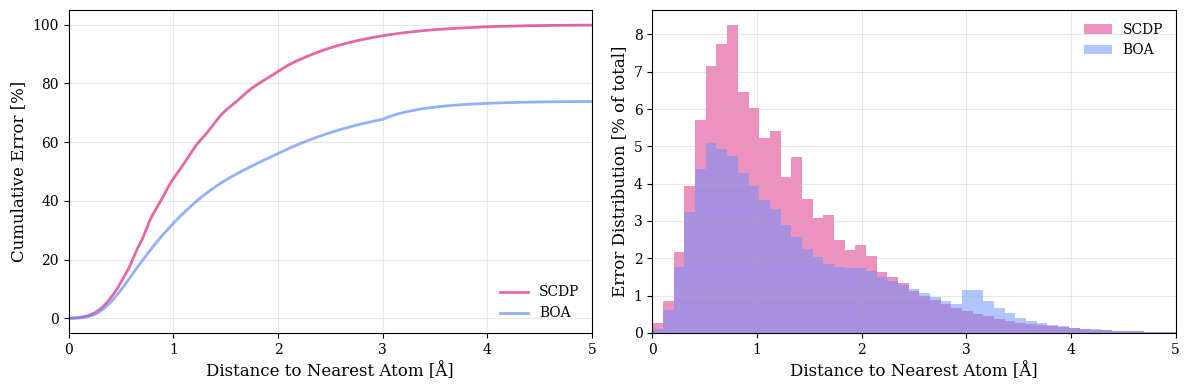


DETAILED COMPARISON

SCDP Predictions (.pt files):
  Samples: 67,916,864
  Mean error: 0.000128
  Median error: 0.000023
  Total error: 8684.059906
  50% error distance: 1.052 Å
  90% error distance: 2.337 Å

BOA Predictions (.npy files):
  Samples: 67,916,864
  Mean error: 0.000095
  Median error: 0.000023
  Total error: 8684.059906
  50% error distance: 1.052 Å
  90% error distance: 2.337 Å

BOA Predictions (.npy files):
  Samples: 67,916,864
  Mean error: 0.000095
  Median error: 0.000022
  Total error: 6424.238905
  50% error distance: 1.647 Å
  90% error distance: 8.616 Å

Relative Performance (BOA vs SCDP):
  Median error: 0.000022
  Total error: 6424.238905
  50% error distance: 1.647 Å
  90% error distance: 8.616 Å

Relative Performance (BOA vs SCDP):
  Mean error ratio: 0.740x
  Median error ratio: 0.990x
  ✅ BOA has 26.0% lower mean error
  Mean error ratio: 0.740x
  Median error ratio: 0.990x
  ✅ BOA has 26.0% lower mean error


In [7]:
# import matplotlib.pyplot as plt

# # Explicitly disable LaTeX and set font to match LaTeX style
# # plt.rcParams['text.usetex'] = False
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman', 'serif']

# # IBM colorblind-safe palette
# ibm_colors = {
#     'blue': '#648FFF',
#     'purple': '#785EF0',
#     'magenta': '#DC267F',
#     'orange': '#FE6100',
#     'yellow': '#FFB000'
# }

# # Create scatter plots
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# alpha = 0.7
# size = 30

# # Plot 1: Time vs num_atoms
# ax = axes[0]
# ax.scatter(df['num_atoms'], df['time'], alpha=0.6, s=size, label='BOA (small cutoff)', color=ibm_colors['blue'], marker='o')
# ax.scatter(df_large_cutoff['num_atoms'], df_large_cutoff['time'], alpha=alpha, s=size, label='BOA (standard cutoff)', color=ibm_colors['magenta'], marker='s')
# ax.scatter(df['num_atoms'], df['time_resnet'] + df['time_init'], alpha=alpha, s=size, label='ResNet', color=ibm_colors['yellow'], marker='^')
# ax.set_xlabel('Number of Atoms', fontsize=12)
# ax.set_ylabel('Time [s]', fontsize=12)
# ax.grid(True, alpha=0.3)
# ax.text(0.05, 0.95, 'A', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top')
# # ax.set_yscale('log')

# # # Add trend line
# # z = np.polyfit(df['num_atoms'], df['time'], 1)
# # p = np.poly1d(z)
# # ax.plot(df['num_atoms'].sort_values(), p(df['num_atoms'].sort_values()), 
# #         "r--", alpha=0.8, label=f'Linear fit: y={z[0]:.2f}x+{z[1]:.2f}')
# ax.legend(loc='upper left', bbox_to_anchor=(0.12, 1.0), frameon=False)

# # Plot 2: NMAPE vs num_atoms
# ax = axes[1]
# ax.scatter(df['num_atoms'], df['nmape'], alpha=alpha, s=size, label='BOA (small cutoff)', color=ibm_colors['blue'], marker='o')
# ax.scatter(df_large_cutoff['num_atoms'], df_large_cutoff['nmape'], alpha=alpha, s=size, label='BOA (standard cutoff)', color=ibm_colors['magenta'], marker='s')
# ax.scatter(df['num_atoms'], df['nmape_resnet']*100, alpha=alpha, s=size, label='ResNet', color=ibm_colors['yellow'], marker='^')
# ax.set_xlabel('Number of Atoms', fontsize=12)
# ax.set_ylabel('NMAE [%]', fontsize=12)
# ax.grid(True, alpha=0.3)
# ax.text(0.05, 0.95, 'B', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top')
# ax.legend(loc='upper left', bbox_to_anchor=(0.12, 1.0), frameon=False)

# plt.tight_layout()
# plt.show()

# # Print statistics
# print("\nStatistics (Small Cutoff):")
# print(f"Time:")
# print(f"  Mean: {df['time'].mean():.4f} s")
# print(f"  Median: {df['time'].median():.4f} s")
# print(f"  Min: {df['time'].min():.4f} s")
# print(f"  Max: {df['time'].max():.4f} s")

# print(f"\nNMAE:")
# print(f"  Mean: {df['nmape'].mean():.6f}")
# print(f"  Median: {df['nmape'].median():.6f}")
# print(f"  Min: {df['nmape'].min():.6f}")
# print(f"  Max: {df['nmape'].max():.6f}")

# print(f"\nStatistics (Large Cutoff):")
# print(f"Time:")
# print(f"  Mean: {df_large_cutoff['time'].mean():.4f} s")
# print(f"  Median: {df_large_cutoff['time'].median():.4f} s")
# print(f"  Min: {df_large_cutoff['time'].min():.4f} s")
# print(f"  Max: {df_large_cutoff['time'].max():.4f} s")

# print(f"\nNMAE:")
# print(f"  Mean: {df_large_cutoff['nmape'].mean():.6f}")
# print(f"  Median: {df_large_cutoff['nmape'].median():.6f}")
# print(f"  Min: {df_large_cutoff['nmape'].min():.6f}")
# print(f"  Max: {df_large_cutoff['nmape'].max():.6f}")

# print(f"\nStatistics (ResNet):")
# print(f"Time (including initialization):")
# print(f"  Mean: {(df['time_resnet'] + df['time_init']).mean():.4f} s")
# print(f"  Median: {(df['time_resnet'] + df['time_init']).median():.4f} s")
# print(f"  Min: {(df['time_resnet'] + df['time_init']).min():.4f} s")
# print(f"  Max: {(df['time_resnet'] + df['time_init']).max():.4f} s")

# print(f"\nNMAE:")
# print(f"  Mean: {(df['nmape_resnet']*100).mean():.6f} %")
# print(f"  Median: {(df['nmape_resnet']*100).median():.6f} %")
# print(f"  Min: {(df['nmape_resnet']*100).min():.6f} %")
# print(f"  Max: {(df['nmape_resnet']*100).max():.6f} %")

# print(f"\nNumber of Atoms:")
# print(f"  Mean: {df['num_atoms'].mean():.1f}")
# print(f"  Median: {df['num_atoms'].median():.1f}")
# print(f"  Min: {df['num_atoms'].min()}")
# print(f"  Max: {df['num_atoms'].max()}")

# # Save figure
# fig.savefig("../data/figures/qmugs_evaluation.pdf", dpi=300)

# Create comparison plot: .pt predictions vs .npy predictions

# Convert to torch tensors for faster computation
npy_errors_torch = torch.from_numpy(npy_errors).to(device)
npy_distances_torch = torch.from_numpy(npy_distances).to(device)
all_errors_torch = torch.from_numpy(all_errors).to(device)
all_distances_torch = torch.from_numpy(all_distances).to(device)

# Calculate cumulative error for .npy predictions using torch
sorted_indices_npy = torch.argsort(npy_distances_torch)
sorted_distances_npy = npy_distances_torch[sorted_indices_npy]
sorted_errors_npy = npy_errors_torch[sorted_indices_npy]

cumulative_error_npy = torch.cumsum(sorted_errors_npy, dim=0)
total_error_npy = cumulative_error_npy[-1]
error_percentage_npy = (cumulative_error_npy / total_error) * 100

# Create distance bins for smoother plot
distance_bins_npy = torch.linspace(0, sorted_distances_npy.max(), 1000, device=device)
# Convert to CPU numpy for interpolation
error_pct_at_distance_npy = np.interp(
    distance_bins_npy.cpu().numpy(), 
    sorted_distances_npy.cpu().numpy(), 
    error_percentage_npy.cpu().numpy()
)
distance_bins_npy = distance_bins_npy.cpu().numpy()

# Calculate cumulative error for original .pt predictions using torch
sorted_indices_pt = torch.argsort(all_distances_torch)
sorted_distances_pt = all_distances_torch[sorted_indices_pt]
sorted_errors_pt = all_errors_torch[sorted_indices_pt]

cumulative_error_pt = torch.cumsum(sorted_errors_pt, dim=0)
total_error_pt = cumulative_error_pt[-1]
error_percentage_pt = (cumulative_error_pt / total_error_pt) * 100

distance_bins_pt = torch.linspace(0, sorted_distances_pt.max(), 1000, device=device)
# Convert to CPU numpy for interpolation
error_pct_at_distance_pt = np.interp(
    distance_bins_pt.cpu().numpy(), 
    sorted_distances_pt.cpu().numpy(), 
    error_percentage_pt.cpu().numpy()
)
distance_bins_pt = distance_bins_pt.cpu().numpy()

# Find distances at 50% and 90% for both
dist_50_pt = distance_bins_pt[np.argmin(np.abs(error_pct_at_distance_pt - 50))]
dist_90_pt = distance_bins_pt[np.argmin(np.abs(error_pct_at_distance_pt - 90))]
dist_50_npy = distance_bins_npy[np.argmin(np.abs(error_pct_at_distance_npy - 50))]
dist_90_npy = distance_bins_npy[np.argmin(np.abs(error_pct_at_distance_npy - 90))]

# Convert total errors to float for printing
total_error_pt = total_error_pt.item()
total_error_npy = total_error_npy.item()

# Explicitly disable LaTeX and set font to match LaTeX style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman', 'serif']

# IBM colorblind-safe palette
ibm_colors = {
    'blue': '#648FFF',
    'purple': '#785EF0',
    'magenta': '#DC267F',
    'orange': '#FE6100',
    'yellow': '#FFB000'
}

# Create comparison plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
alpha = 0.7

# Subplot 1: Cumulative error percentage
ax1.plot(distance_bins_pt, error_pct_at_distance_pt, linewidth=2, 
        color=ibm_colors['magenta'], label='SCDP', alpha=alpha)
ax1.plot(distance_bins_npy, error_pct_at_distance_npy, linewidth=2, 
        color=ibm_colors['blue'], label='BOA', alpha=alpha)
ax1.set_xlabel('Distance to Nearest Atom [Å]', fontsize=12)
ax1.set_ylabel('Cumulative Error [%]', fontsize=12)
ax1.set_xlim(0, 5)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', frameon=False)

# Subplot 2: Error histogram
hist_bins = np.linspace(0, 5, 50)

# Calculate histograms
hist_pt, _ = np.histogram(all_distances, bins=hist_bins, weights=all_errors)
hist_npy, _ = np.histogram(npy_distances, bins=hist_bins, weights=npy_errors)
bin_centers = (hist_bins[:-1] + hist_bins[1:]) / 2

# Normalize histograms to percentage of total error
hist_pt_pct = (hist_pt / total_error_pt) * 100
hist_npy_pct = (hist_npy / total_error_pt) * 100

ax2.bar(bin_centers, hist_pt_pct, width=(hist_bins[1]-hist_bins[0]), 
        alpha=0.5, color=ibm_colors['magenta'], label='SCDP')
ax2.bar(bin_centers, hist_npy_pct, width=(hist_bins[1]-hist_bins[0]), 
        alpha=0.5, color=ibm_colors['blue'], label='BOA')
ax2.set_xlabel('Distance to Nearest Atom [Å]', fontsize=12)
ax2.set_ylabel('Error Distribution [% of total]', fontsize=12)
ax2.set_xlim(0, 5)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', frameon=False)

plt.tight_layout()

# save figure
fig.savefig("../data/figures/qm9_boa_scdp_error_comparison.pdf", dpi=300)
plt.show()

# Print detailed comparison
print(f"\n{'='*60}")
print("DETAILED COMPARISON")
print(f"{'='*60}")
print(f"\nSCDP Predictions (.pt files):")
print(f"  Samples: {len(all_errors):,}")
print(f"  Mean error: {all_errors.mean():.6f}")
print(f"  Median error: {np.median(all_errors):.6f}")
print(f"  Total error: {total_error_pt:.6f}")
print(f"  50% error distance: {dist_50_pt:.3f} Å")
print(f"  90% error distance: {dist_90_pt:.3f} Å")

print(f"\nBOA Predictions (.npy files):")
print(f"  Samples: {len(npy_errors):,}")
print(f"  Mean error: {npy_errors.mean():.6f}")
print(f"  Median error: {np.median(npy_errors):.6f}")
print(f"  Total error: {total_error_npy:.6f}")
print(f"  50% error distance: {dist_50_npy:.3f} Å")
print(f"  90% error distance: {dist_90_npy:.3f} Å")

print(f"\nRelative Performance (BOA vs SCDP):")
mean_ratio = npy_errors.mean() / all_errors.mean()
median_ratio = np.median(npy_errors) / np.median(all_errors)
print(f"  Mean error ratio: {mean_ratio:.3f}x")
print(f"  Median error ratio: {median_ratio:.3f}x")
if mean_ratio < 1:
    print(f"  ✅ BOA has {(1-mean_ratio)*100:.1f}% lower mean error")
else:
    print(f"  ❌ BOA has {(mean_ratio-1)*100:.1f}% higher mean error")

Processing 100 files for SCDP predictions...


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:08<00:00, 12.04it/s]




Recalculating distances for BOA predictions (matching 100 SCDP molecules)...


100%|██████████| 100/100 [00:07<00:00, 12.88it/s]




SCDP: 67,916,864 points
BOA: 67,916,864 points


100%|██████████| 100/100 [00:02<00:00, 36.18it/s]



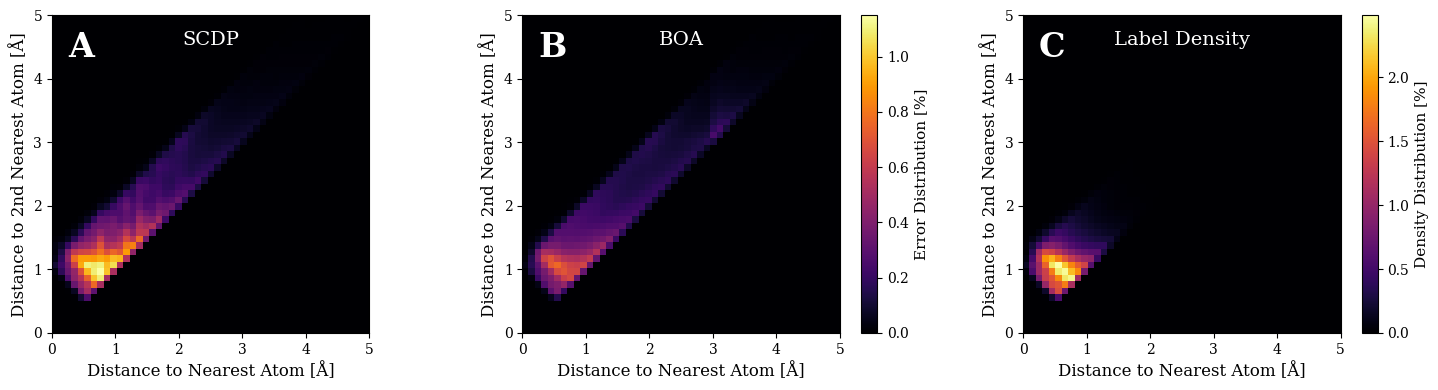


2D Histogram Statistics:

SCDP Error:
  Non-zero bins: 599
  Total error: 8659.957767
  Mean absolute error (all bins): 0.000374
  Max bin error %: 1.15%

BOA Error:
  Non-zero bins: 599
  Total error: 6400.061612
  Mean absolute error (all bins): 0.000213
  Max bin error %: 0.76%

Density Distribution:
  Total density: 5081273.490742
  Total density: 5081273.490742
  Total density: 5081273.490742
  Max bin density %: 2.49%


In [45]:
# 2D Histogram: Error vs Distance to Nearest and Second-Nearest Atom

# Subsampling control - set to None to use all files, or an integer to limit
n_files_subsample = 100  # Number of files to process (None for all)

# First, recalculate distances to get both nearest and second-nearest for SCDP
all_distances_1st = []
all_distances_2nd = []
all_errors_2d = []

# Determine which files to process
files_to_process = pred_files[:n_files_subsample] if n_files_subsample is not None else pred_files

print(f"Processing {len(files_to_process)} files for SCDP predictions...")
for pred_file in tqdm(files_to_process):
    try:
        data = torch.load(pred_file, weights_only=False)
        
        # Extract prediction and label tensors (keep on GPU)
        prediction = data['prediction'].to(device).flatten()
        label = data['label'].to(device).flatten()
        
        # Calculate absolute error on GPU
        abs_error = torch.abs(prediction - label)
        
        # Get batch object
        batch = data['batch']
        
        # Get probe coordinates (keep on GPU)
        probe_coords = batch.probe_coords.to(device)
        
        # Get atom coordinates (mask virtual nodes, keep on GPU)
        is_vnode = batch.is_vnode.to(device)
        atom_coords = batch.coords.to(device)[~is_vnode]
        
        # Compute distance from each probe point to all atoms on GPU
        distances = torch.cdist(probe_coords.unsqueeze(0), atom_coords.unsqueeze(0)).squeeze(0)
        
        # Get the two smallest distances for each probe point
        sorted_distances, _ = torch.sort(distances, dim=1)
        min_distances_1st = sorted_distances[:, 0]  # Nearest atom
        min_distances_2nd = sorted_distances[:, 1] if sorted_distances.shape[1] > 1 else sorted_distances[:, 0]  # Second nearest
        
        # Move results to CPU and convert to numpy for storage
        all_errors_2d.extend(abs_error.cpu().numpy().tolist())
        all_distances_1st.extend(min_distances_1st.cpu().numpy().tolist())
        all_distances_2nd.extend(min_distances_2nd.cpu().numpy().tolist())
        
    except Exception as e:
        print(f"Error processing {pred_file.name}: {e}")
        continue

# Convert to numpy arrays
all_errors_2d = np.array(all_errors_2d)
all_distances_1st = np.array(all_distances_1st)
all_distances_2nd = np.array(all_distances_2nd)

# Now do the same for BOA predictions - but only for molecules that were processed for SCDP
# First, get the test indices from the processed SCDP files
processed_test_indices = set()
for pred_file in files_to_process:
    try:
        data = torch.load(pred_file, weights_only=False)
        test_index = data['test_index'].item() if torch.is_tensor(data['test_index']) else data['test_index']
        processed_test_indices.add(test_index)
    except Exception as e:
        continue

npy_distances_1st = []
npy_distances_2nd = []
npy_errors_2d = []

print(f"\nRecalculating distances for BOA predictions (matching {len(processed_test_indices)} SCDP molecules)...")
for npy_entry in tqdm(npy_id_mapping):
    test_index = npy_entry['test_index']
    
    # Only process if this molecule was processed for SCDP
    if test_index is None or test_index not in processed_test_indices:
        continue
    
    if test_index not in pt_index_to_file:
        continue
    
    try:
        # Load .npy prediction
        npy_prediction = np.load(npy_entry['path'])
        
        # Load corresponding .pt file with label
        pt_file = pt_index_to_file[test_index]
        pt_data = torch.load(pt_file, weights_only=False)
        
        # Get label and batch
        label = pt_data['label'].to(device).flatten()
        batch = pt_data['batch']
        
        # Convert npy to torch tensor
        npy_pred_tensor = torch.from_numpy(npy_prediction).to(device).flatten().float()
        
        # Check if shapes match
        if npy_pred_tensor.shape[0] != label.shape[0]:
            continue
        
        # Calculate absolute error
        abs_error = torch.abs(npy_pred_tensor - label)
        
        # Get probe coordinates and atom coordinates
        probe_coords = batch.probe_coords.to(device)
        is_vnode = batch.is_vnode.to(device)
        atom_coords = batch.coords.to(device)[~is_vnode]
        
        # Compute distances
        distances = torch.cdist(probe_coords.unsqueeze(0), atom_coords.unsqueeze(0)).squeeze(0)
        
        # Get the two smallest distances for each probe point
        sorted_distances, _ = torch.sort(distances, dim=1)
        min_distances_1st = sorted_distances[:, 0]  # Nearest atom
        min_distances_2nd = sorted_distances[:, 1] if sorted_distances.shape[1] > 1 else sorted_distances[:, 0]  # Second nearest
        
        # Store results
        npy_errors_2d.extend(abs_error.cpu().numpy().tolist())
        npy_distances_1st.extend(min_distances_1st.cpu().numpy().tolist())
        npy_distances_2nd.extend(min_distances_2nd.cpu().numpy().tolist())
        
    except Exception as e:
        continue

# Convert to numpy arrays
npy_errors_2d = np.array(npy_errors_2d)
npy_distances_1st = np.array(npy_distances_1st)
npy_distances_2nd = np.array(npy_distances_2nd)

print(f"\nSCDP: {len(all_errors_2d):,} points")
print(f"BOA: {len(npy_errors_2d):,} points")

# Collect density values for density distribution (subplot C)
# Only need to collect once since both methods use the same ground truth
all_densities_pt = []

print(f"Collecting ground truth density values...")
for pred_file in tqdm(files_to_process):
    try:
        data = torch.load(pred_file, weights_only=False)
        label = data['label'].to(device).flatten()
        all_densities_pt.extend(label.cpu().numpy().tolist())
    except Exception as e:
        continue

all_densities_pt = np.array(all_densities_pt)

# Create 2D histograms with 3 panels
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Define bins
x_bins = np.linspace(0, 5, 50)  # Distance to nearest atom
y_bins = np.linspace(0, 5, 50)  # Distance to second-nearest atom

# SCDP 2D histogram - error
hist_pt, xedges, yedges = np.histogram2d(
    all_distances_1st, all_distances_2nd, 
    bins=[x_bins, y_bins], 
    weights=all_errors_2d
)
# Normalize by count to get mean error in each bin
count_pt, _, _ = np.histogram2d(
    all_distances_1st, all_distances_2nd, 
    bins=[x_bins, y_bins]
)

# BOA 2D histogram - error
hist_npy, xedges, yedges = np.histogram2d(
    npy_distances_1st, npy_distances_2nd, 
    bins=[x_bins, y_bins], 
    weights=npy_errors_2d
)
# Normalize by count to get mean error in each bin
count_npy, _, _ = np.histogram2d(
    npy_distances_1st, npy_distances_2nd, 
    bins=[x_bins, y_bins]
)

# Density 2D histogram
hist_density_pt, _, _ = np.histogram2d(
    all_distances_1st, all_distances_2nd, 
    bins=[x_bins, y_bins], 
    weights=all_densities_pt
)

# Normalize histograms to percentage of total
hist_pt_pct = (hist_pt / hist_pt.sum()) * 100
hist_npy_pct = (hist_npy / hist_pt.sum()) * 100
hist_density_pt_pct = (hist_density_pt / hist_density_pt.sum()) * 100

# Get mean error per bin
mean_error_pt = np.divide(hist_pt, count_pt, where=count_pt>0, out=np.zeros_like(hist_pt))
mean_error_npy = np.divide(hist_npy, count_npy, where=count_npy>0, out=np.zeros_like(hist_npy))

# Determine common colorbar range for error plots
vmin = 0
vmax = max(hist_pt_pct.max(), hist_npy_pct.max())

# Plot A: SCDP - percentage of total error
im1 = ax1.imshow(hist_pt_pct.T, origin='lower', aspect='equal',
                 extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                 cmap='inferno', interpolation='nearest', vmin=vmin, vmax=vmax)
ax1.set_xlabel('Distance to Nearest Atom [Å]', fontsize=12)
ax1.set_ylabel('Distance to 2nd Nearest Atom [Å]', fontsize=12)
ax1.text(0.05, 0.95, 'A', transform=ax1.transAxes, fontsize=24, fontweight='bold', 
         va='top', color='white')
ax1.text(0.5, 0.95, 'SCDP', transform=ax1.transAxes, fontsize=14, 
         va='top', ha='center', color='white')

# Plot B: BOA - percentage of total error
im2 = ax2.imshow(hist_npy_pct.T, origin='lower', aspect='equal',
                 extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                 cmap='inferno', interpolation='nearest', vmin=vmin, vmax=vmax)
ax2.set_xlabel('Distance to Nearest Atom [Å]', fontsize=12)
ax2.set_ylabel('Distance to 2nd Nearest Atom [Å]', fontsize=12)
ax2.text(0.05, 0.95, 'B', transform=ax2.transAxes, fontsize=24, fontweight='bold', 
         va='top', color='white')
ax2.text(0.5, 0.95, 'BOA', transform=ax2.transAxes, fontsize=14, 
         va='top', ha='center', color='white')
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label('Error Distribution [%]', fontsize=11)

# Plot C: Density distribution
im3 = ax3.imshow(hist_density_pt_pct.T, origin='lower', aspect='equal',
                 extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
                 cmap='inferno', interpolation='nearest')
ax3.set_xlabel('Distance to Nearest Atom [Å]', fontsize=12)
ax3.set_ylabel('Distance to 2nd Nearest Atom [Å]', fontsize=12)
ax3.text(0.05, 0.95, 'C', transform=ax3.transAxes, fontsize=24, fontweight='bold', 
         va='top', color='white')
ax3.text(0.5, 0.95, 'Label Density', transform=ax3.transAxes, fontsize=14, 
         va='top', ha='center', color='white')
cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label('Density Distribution [%]', fontsize=11)

plt.tight_layout()
# save figure
fig.savefig("../data/figures/qm9_boa_scdp_2d_histogram_comparison.pdf", dpi=300)
plt.show()

# Print statistics
print(f"\n2D Histogram Statistics:")
print(f"\nSCDP Error:")
print(f"  Non-zero bins: {np.count_nonzero(count_pt)}")
print(f"  Total error: {hist_pt.sum():.6f}")
print(f"  Mean absolute error (all bins): {mean_error_pt[count_pt > 0].mean():.6f}")
print(f"  Max bin error %: {hist_pt_pct[count_pt > 0].max():.2f}%")

print(f"\nBOA Error:")
print(f"  Non-zero bins: {np.count_nonzero(count_npy)}")
print(f"  Total error: {hist_npy.sum():.6f}")
print(f"  Mean absolute error (all bins): {mean_error_npy[count_npy > 0].mean():.6f}")
print(f"  Max bin error %: {hist_npy_pct[count_npy > 0].max():.2f}%")

print(f"\nDensity Distribution:")

print(f"  Total density: {hist_density_pt.sum():.6f}")
print(f"  Total density: {hist_density_pt.sum():.6f}")
print(f"  Total density: {hist_density_pt.sum():.6f}")
print(f"  Max bin density %: {hist_density_pt_pct.max():.2f}%")

Subsampled to 100,000 points per method


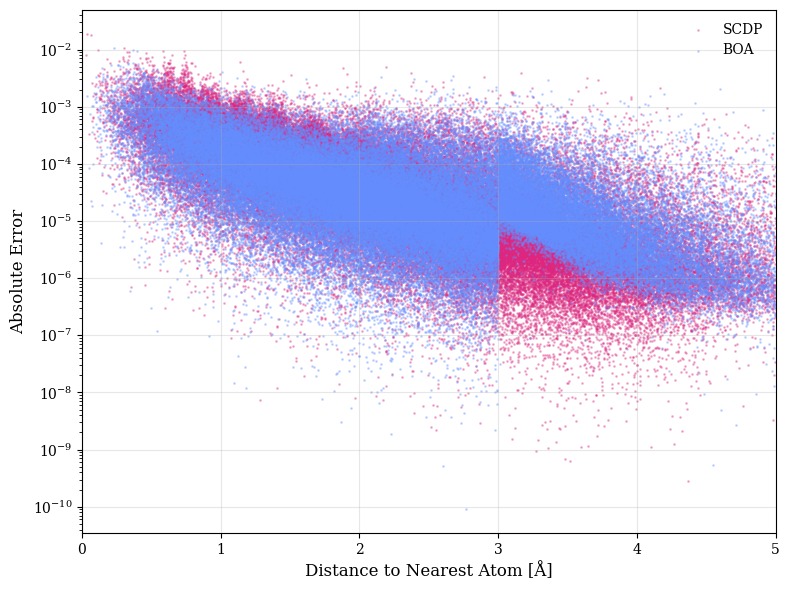


Scatter plot statistics:
SCDP: mean=0.000127, median=0.000023
BOA: mean=0.000094, median=0.000022


In [10]:
# Scatter plot: Error vs Distance to Nearest Atom

# Subsample control - set to None to plot all points, or an integer to limit
n_subsample = 100000  # Number of points to plot per method

# Explicitly disable LaTeX and set font to match LaTeX style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman', 'serif']

# IBM colorblind-safe palette
ibm_colors = {
    'blue': '#648FFF',
    'purple': '#785EF0',
    'magenta': '#DC267F',
    'orange': '#FE6100',
    'yellow': '#FFB000'
}

# Subsample data if requested
if n_subsample is not None and n_subsample < len(all_errors):
    # Random subsample for SCDP
    indices_pt = np.random.choice(len(all_errors), n_subsample, replace=False)
    plot_distances_pt = all_distances[indices_pt]
    plot_errors_pt = all_errors[indices_pt]
    
    # Random subsample for BOA
    indices_npy = np.random.choice(len(npy_errors), n_subsample, replace=False)
    plot_distances_npy = npy_distances[indices_npy]
    plot_errors_npy = npy_errors[indices_npy]
    
    print(f"Subsampled to {n_subsample:,} points per method")
else:
    plot_distances_pt = all_distances
    plot_errors_pt = all_errors
    plot_distances_npy = npy_distances
    plot_errors_npy = npy_errors
    print(f"Plotting all {len(all_errors):,} SCDP points and {len(npy_errors):,} BOA points")

# Create scatter plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
alpha = 0.3
size = 1

# Scatter plot with error vs distance
ax.scatter(plot_distances_pt, plot_errors_pt, s=size, alpha=alpha, 
          color=ibm_colors['magenta'], label='SCDP', rasterized=True)
ax.scatter(plot_distances_npy, plot_errors_npy, s=size, alpha=alpha, 
          color=ibm_colors['blue'], label='BOA', rasterized=True)

ax.set_xlabel('Distance to Nearest Atom [Å]', fontsize=12)
ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_xlim(0, 5)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout()
plt.show()

# Print statistics for the subsampled data
print(f"\nScatter plot statistics:")
print(f"SCDP: mean={plot_errors_pt.mean():.6f}, median={np.median(plot_errors_pt):.6f}")
print(f"BOA: mean={plot_errors_npy.mean():.6f}, median={np.median(plot_errors_npy):.6f}")